In [1]:

# imports
import os
import sys
import types
import json

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = fig_dpi
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  pio.renderers.default = "notebook_connected"
except Exception:
  pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass



# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
if r'':
  os.chdir(r'')

# reset state
%reset

def ojs_define(**kwargs):
  import json
  from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v
  
  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define


/var/folders/l7/qksjftz12pz0s32y0l3jd4k4cyyb65/T/ipykernel_51600/3347640643.py:20: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats(fig_format)


{"/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/importlib/_bootstrap.py": 1675782615.0, "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/importlib/_bootstrap_external.py": 1675782615.0, "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/zipimport.py": 1675782614.0, "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/codecs.py": 1675782614.0, "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/encodings/aliases.py": 1675782615.0, "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/encodings/__init__.py": 1675782615.0, "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/encodings/utf_8.py": 1675782615.0, "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/abc.py": 1675782614.0, "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/io.py": 1675782614.0, "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/stat.py": 1675782614.0, "/Libr

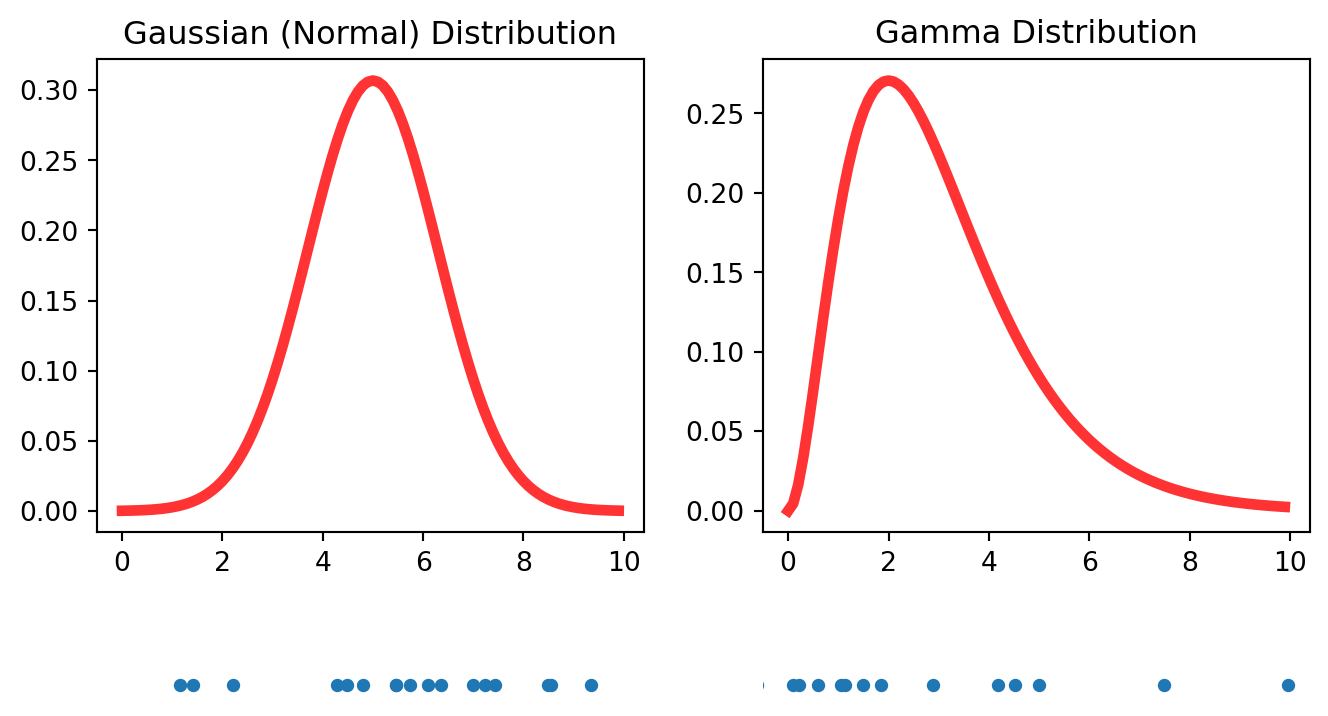

In [2]:
#| eval: true
#| echo: false
from scipy.stats import norm,gamma
from matplotlib import pyplot as plt
import numpy as np

x = np.arange(0,10,0.1)

fig,ax = plt.subplots(2,2)

μ = 5
σ = 1.3

ax[0][0].plot(x,norm.pdf(x,loc = μ,scale = σ),'r-',lw=4,alpha = 0.8)

a = 3

dataGamma = gamma.rvs(a,scale = 0.5,size = 10000)

ax[0][1].plot(x,gamma.pdf(x,a),'r-',lw=4,alpha = 0.8)



dataNorm = norm.rvs(loc = μ,scale = σ,size = 20)

ax[1][0].plot(dataNorm,[0.25 for x in dataNorm],'.',axes = None,ms = 8)
ax[1][0].set_xlim(2,7)
ax[1][0].set_aspect(8)
ax[1][0].spines['top'].set_visible(False)
ax[1][0].spines['left'].set_visible(False)
ax[1][0].spines['right'].set_visible(False)
ax[1][0].spines['bottom'].set_visible(False)
ax[1][0].set_yticks([])
ax[1][0].set_xticks([])
ax[0][0].set_title("Gaussian (Normal) Distribution")



dataGamma = gamma.rvs(a,size = 20)

ax[1][1].plot(dataGamma,[0.25 for x in dataGamma],'.',axes = None,ms = 8)
ax[1][1].set_xlim(2,7)
ax[1][1].set_aspect(8)
ax[1][1].spines['top'].set_visible(False)
ax[1][1].spines['left'].set_visible(False)
ax[1][1].spines['right'].set_visible(False)
ax[1][1].spines['bottom'].set_visible(False)
ax[1][1].set_yticks([])
ax[1][1].set_xticks([])
ax[0][1].set_title("Gamma Distribution")


plt.tight_layout()
plt.show()

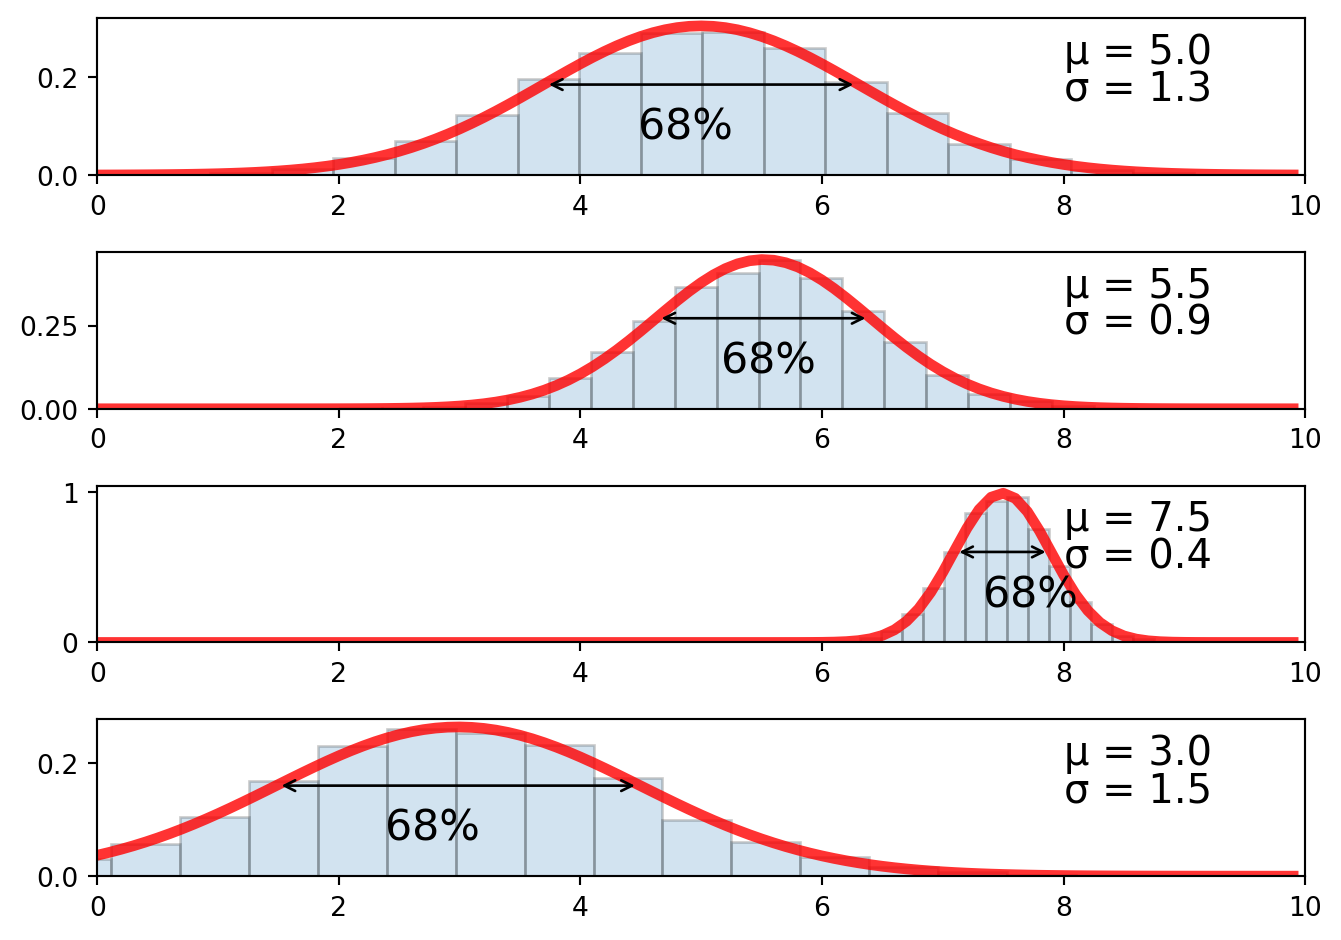

In [3]:
#| eval: true
#| echo: false

from scipy.stats import norm
from matplotlib import pyplot as plt
import numpy as np

x = np.arange(0,10,0.1)

def makePlot(μ,σ,ax):
    data = norm.rvs(loc = μ,scale = σ,size = 10000)
    μ = np.mean(data)
    σ = np.std(data)
    height = norm.pdf(μ- σ,loc = μ,scale = σ)
    peak = norm.pdf(μ,loc = μ,scale = σ)
    ax.plot(x,norm.pdf(x,loc = μ,scale = σ),'r-',lw=4,alpha = 0.8)
    ax.hist(data,density = True,alpha = 0.2,bins = 20,edgecolor = "black")
    ax.annotate(text='', xy=(μ + σ,height), xytext=(μ - σ,height), arrowprops=dict(arrowstyle='<->'))
    ax.annotate(text='68%', xy=(μ - 0.4 * σ,0.4*height), xytext=(μ - 0.4 * σ,0.4*height),fontsize = 16)
    ax.annotate(text=f"μ = {μ:3.1f}",xy=(8,0.75 * peak),xytext=(8,0.75 * peak),fontsize = 15)
    ax.annotate(text=f"σ = {σ:3.1f}",xy=(8,0.5 * peak),xytext=(8,0.5 * peak),fontsize = 15)
    ax.set_xlim(0,10)
    
fig,ax = plt.subplots(4)

makePlot(5,1.3,ax[0])
makePlot(5.5,0.9,ax[1])
makePlot(7.5,0.4,ax[2])
makePlot(3.0,1.5,ax[3])
plt.tight_layout()
plt.show()

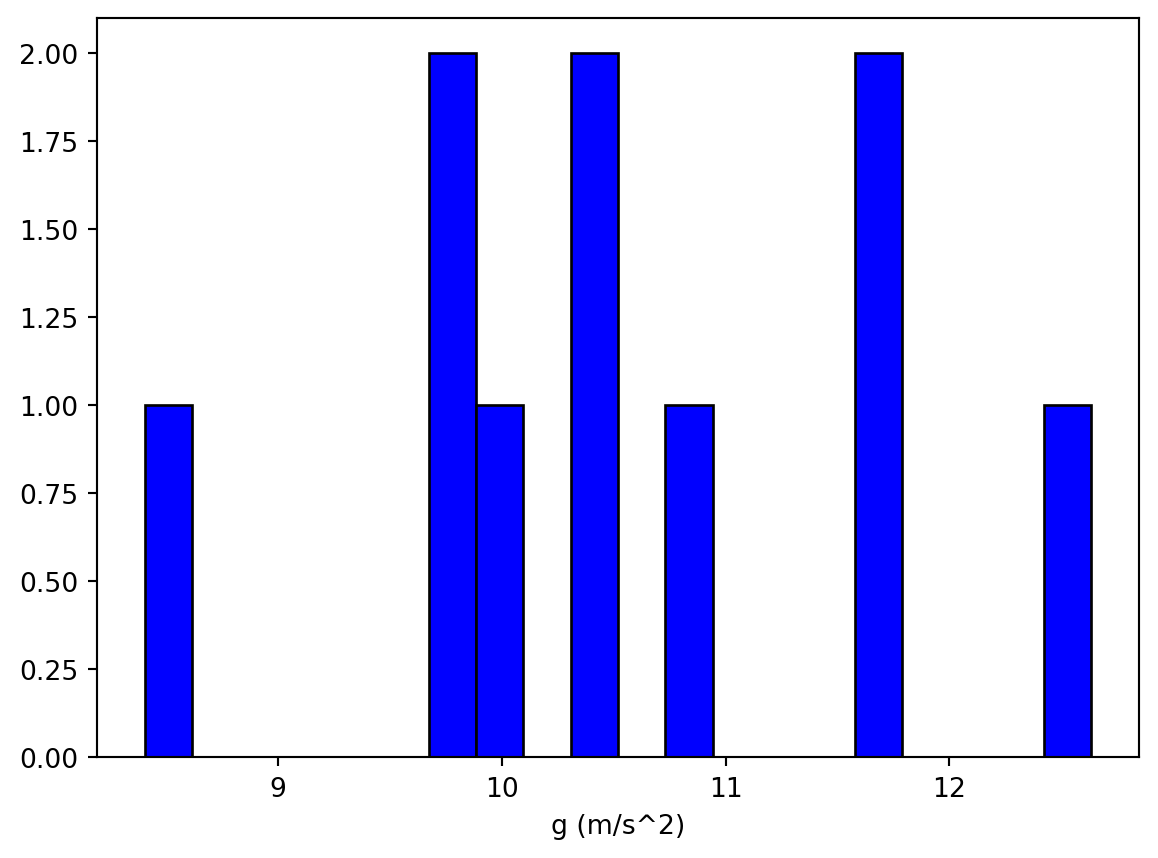

In [4]:
#| echo: false
#| eval: true
#| output: true
import matplotlib.pyplot as plt
import numpy.random as rand

data = rand.normal(10.5,1.25,10) # Dummy data just for this example.

ax = plt.axes()
ax.hist(data,bins = 20,color = 'blue',edgecolor = 'black')
ax.set_xlabel("g (m/s^2)")
plt.show()

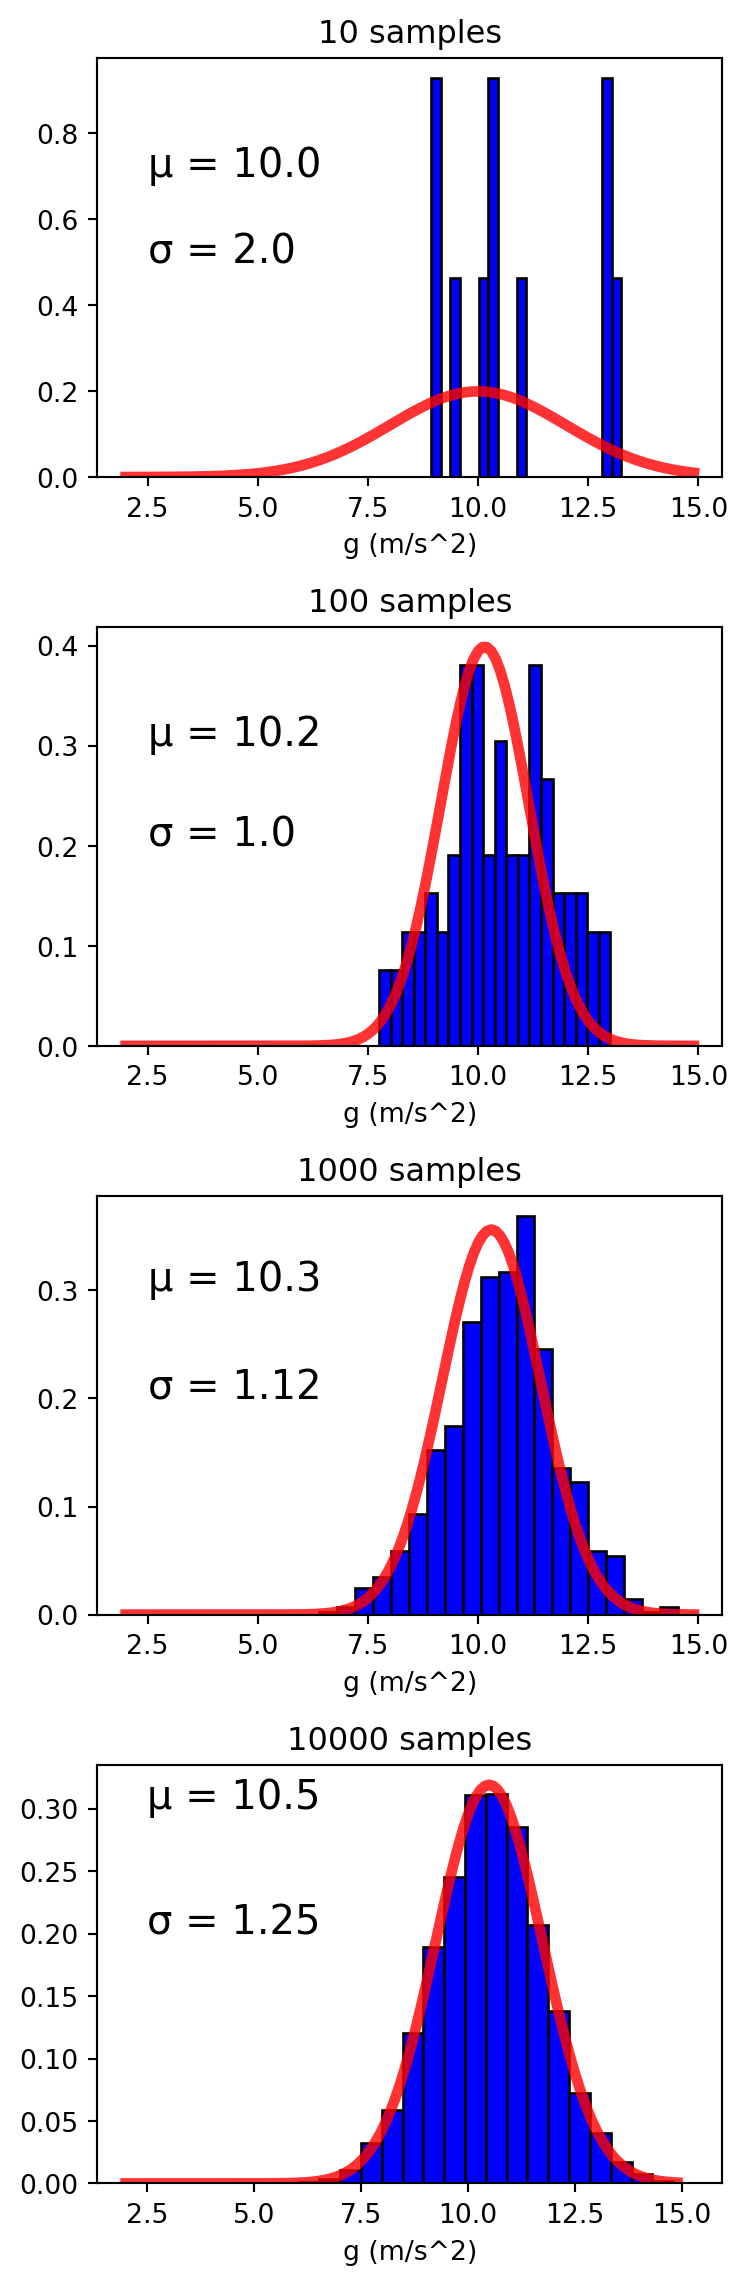

In [5]:
#| eval: true
#| echo: false
#| fig-cap: "As more measurements are performed the level of confidence in the mean and standard deviation increase"

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy.random as rand
import numpy as np

x = np.arange(2,15,0.1)

fig,ax = plt.subplots(4,1,figsize= (4,12))

#ax = plt.axes()
ax[0].hist(rand.normal(10.5,1.25,10),bins = 20,color = 'blue',edgecolor = 'black',density = True)
ax[0].plot(x,norm.pdf(x,loc = 10,scale = 2),'r-',lw=4,alpha = 0.8)
ax[0].set_xlabel("g (m/s^2)")
ax[0].set_title("10 samples")
ax[0].annotate(text=f"μ = {10:3.1f}",xy=(2.5,0.7),xytext=(2.5,0.7),fontsize = 15)
ax[0].annotate(text=f"σ = {2:3.1f}",xy=(2.5,0.5),xytext=(2.5,0.5),fontsize = 15)
#ax[0].set_aspect(0.8)

ax[1].hist(rand.normal(10.5,1.25,100),bins = 20,color = 'blue',edgecolor = 'black',density = True)
ax[1].plot(x,norm.pdf(x,loc = 10.15,scale = 1),'r-',lw=4,alpha = 0.8)
ax[1].set_xlabel("g (m/s^2)")
ax[1].set_title("100 samples")
ax[1].annotate(text=f"μ = {10.15:3.1f}",xy=(2.5,0.3),xytext=(2.5,0.3),fontsize = 15)
ax[1].annotate(text=f"σ = {1:3.1f}",xy=(2.5,0.2),xytext=(2.5,0.2),fontsize = 15)
#ax[1].set_aspect(0.3)

ax[2].hist(rand.normal(10.5,1.25,1000),bins = 20,color = 'blue',edgecolor = 'black',density = True)
ax[2].plot(x,norm.pdf(x,loc = 10.3,scale = 1.12),'r-',lw=4,alpha = 0.8)
ax[2].set_xlabel("g (m/s^2)")
ax[2].set_title("1000 samples")
ax[2].annotate(text=f"μ = {10.3:3.1f}",xy=(2.5,0.3),xytext=(2.5,0.3),fontsize = 15)
ax[2].annotate(text=f"σ = {1.12:3.2f}",xy=(2.5,0.2),xytext=(2.5,0.2),fontsize = 15)
#ax[2].set_aspect(0.045)

ax[3].hist(rand.normal(10.5,1.25,10000),bins = 20,color = 'blue',edgecolor = 'black',density = True)
ax[3].plot(x,norm.pdf(x,loc = 10.5,scale = 1.25),'r-',lw=4,alpha = 0.8)
ax[3].set_xlabel("g (m/s^2)")
ax[3].set_title("10000 samples")
ax[3].annotate(text=f"μ = {10.5:3.1f}",xy=(2.5,0.3),xytext=(2.5,0.3),fontsize = 15)
ax[3].annotate(text=f"σ = {1.25:3.2f}",xy=(2.5,0.2),xytext=(2.5,0.2),fontsize = 15)
fig.tight_layout()
plt.show()

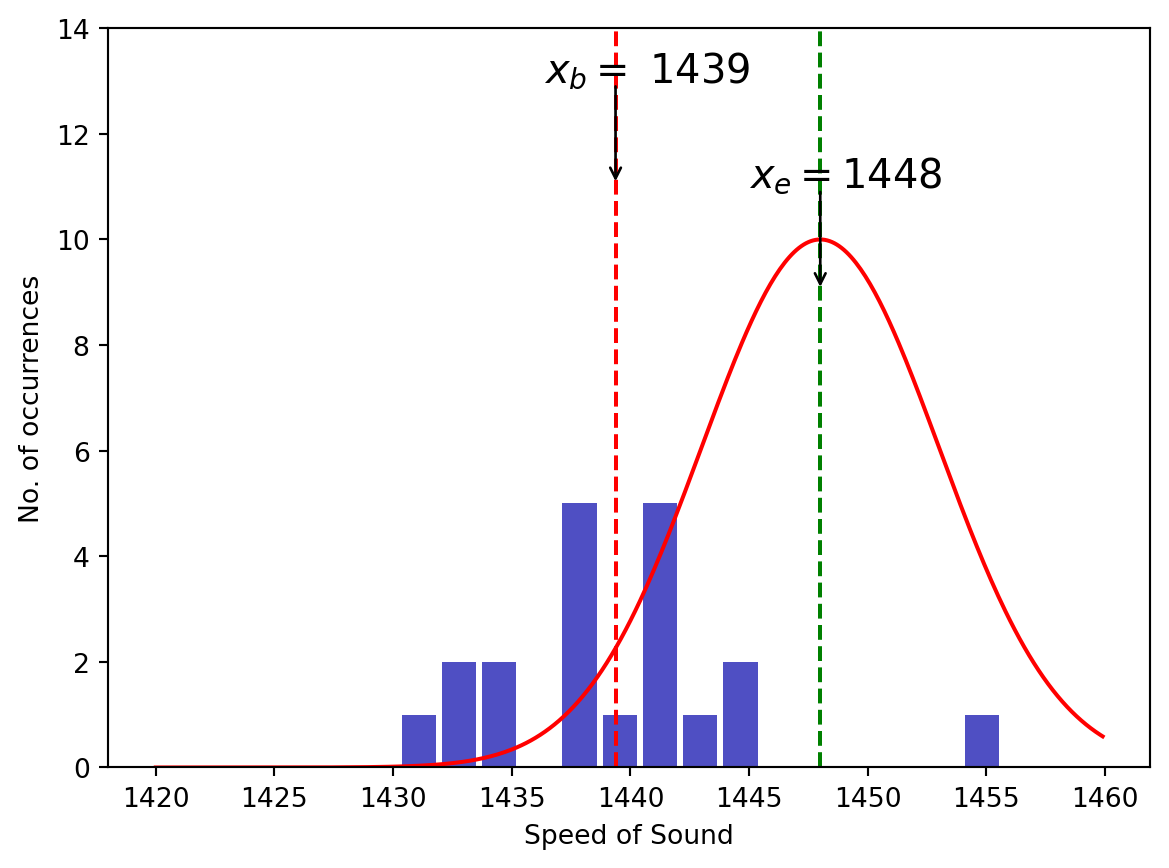

In [6]:
#| eval: true
#| echo: false

from matplotlib import pyplot as plt
from numpy import arange,exp,linspace,random,mean

x = arange(1420,1460,.1)
y = 10*exp(-(x-1448)**2/(2 * 5**2))

data = random.normal(1440,5,20)
μ = mean(data)
plt.hist(data,bins = 15,alpha = 0.7,rwidth = 0.85,color='#0504aa')
plt.plot(x,y,'r-')
plt.plot([μ for x in range(5)],linspace(0,15,5),'r--') 
plt.plot([1448 for x in range(5)],linspace(0,15,5),'g--') 
plt.xlabel("Speed of Sound")
plt.ylabel("No. of occurrences")
plt.ylim(0,14)
plt.annotate(text=fr"$x_e = 1448$",xy=(1445,11),xytext=(1445,11),fontsize = 15)
plt.annotate(text=fr"$x_b = $ {μ:4.0f}",xy=(μ-3,11),xytext=(μ-3,13),fontsize = 15)
plt.annotate(text='', xy=(1448,9), xytext=(1448,11), arrowprops=dict(arrowstyle='->'))
plt.annotate(text='', xy=(μ,11), xytext=(μ,13), arrowprops=dict(arrowstyle='->'))

plt.show()

In [7]:
from scipy.stats import ttest_1samp
results = [1.64,1.57,1.72,1.55,1.68,1.62,1.70,1.59]

expected_value = 1.67
P = ttest_1samp(results,expected_value)

print(P)

TtestResult(statistic=-1.6451950239004052, pvalue=0.14392654580468714, df=7)


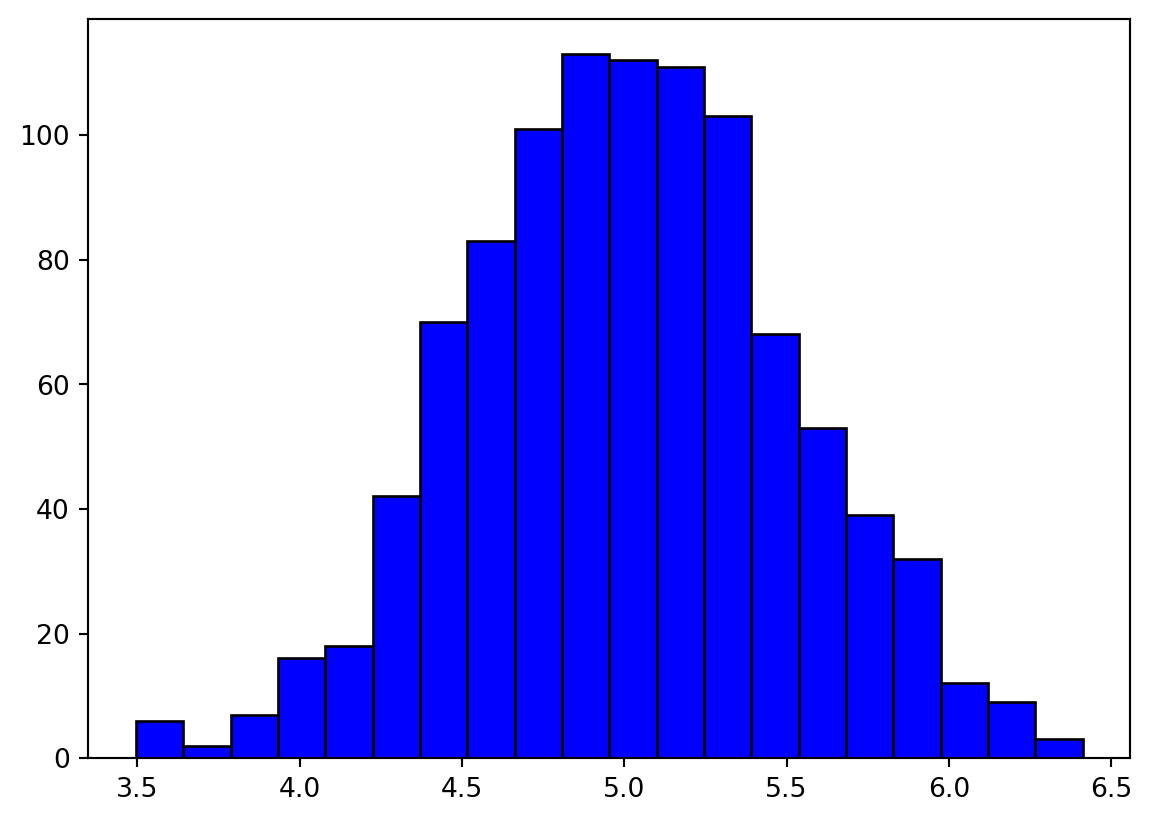

In [8]:
import matplotlib.pyplot as plt
import numpy.random as rand

data = rand.normal(5,.5,1000) # Dummy data just for this example.

ax = plt.axes()
ax.hist(data,bins = 20,color = 'blue',edgecolor = 'black')
plt.show()

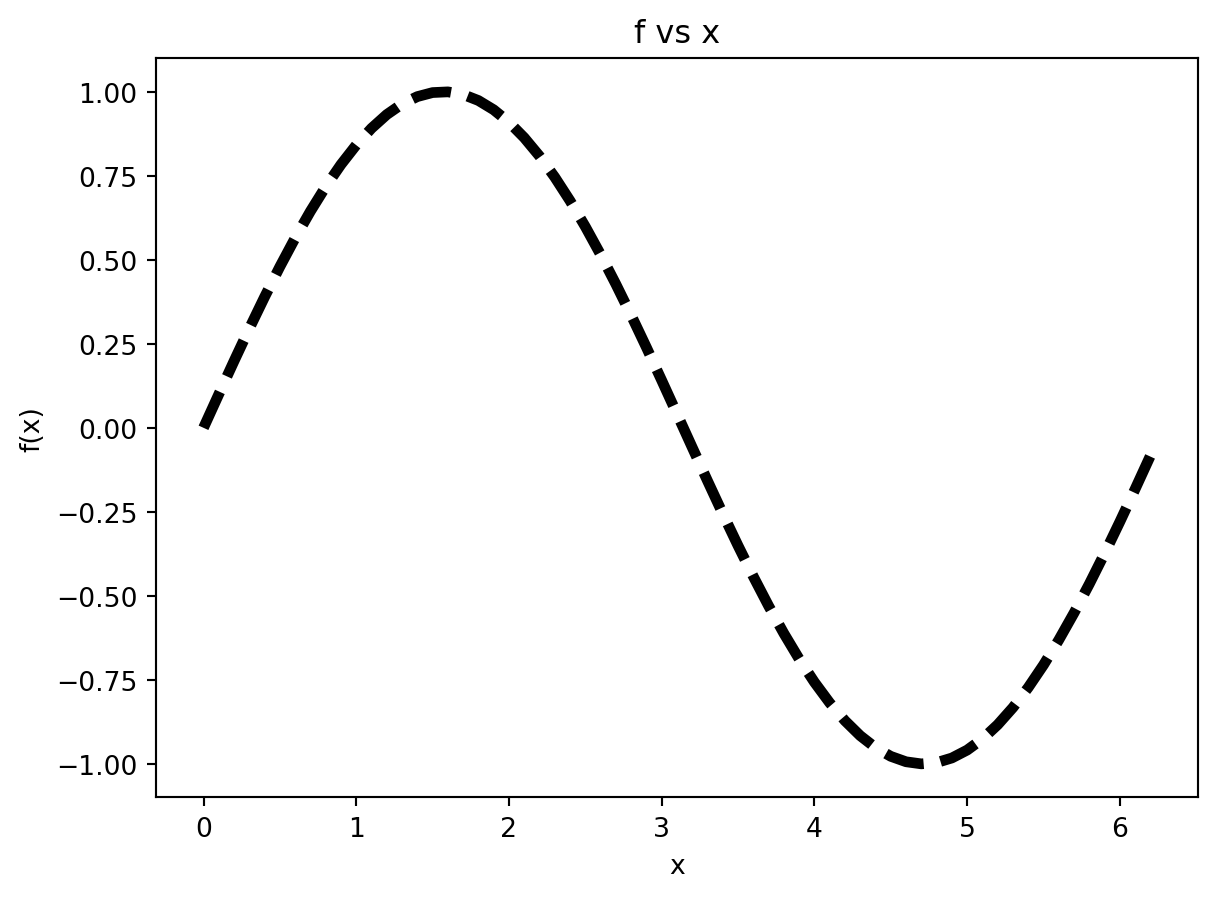

In [9]:
#| eval: true
#| echo: true
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(0,2 * np.pi,0.1) # Step 1
y = np.sin(x)                  # Step 2
ax = plt.axes()
ax.plot(x,y,linewidth = 4,color = 'black',linestyle = "--")  # Step 3
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("f vs x")
plt.show()                     # Step 4

In [10]:
#| eval: false
#| echo: true

import numpy as np
import statistics as stats
import math as mt

%matplotlib inline

T = np.loadtxt("pendulum_data.txt",float)  # Line 7
N = len(T)     # Find the number of data points.
g =            # Line 9
meanG =        # Line 10
stdG =         # Line 11
stdMeanG =     # Line 12

μ =            # Line 14 
σ =            # Line 15
σ_μ =          # Line 16




ax = plt.axes()
# Plot the histogram and Normal distribution below.

plt.plot(x,norm_data)
plt.xlabel('g (m/s^2)')
plt.ylabel('Probability')
plt.show()

In [11]:
#| eval: false
#| echo: true

from scipy.stats import poisson,norm
from numpy import arange
from matplotlib import pyplot as plt

#data = np.loadtxt("radiation_data.txt",float)

#μ =   # Line 7
#σ =   # Line 8

ax = plt.axes()
              # Line 11

dist = poisson(μ)
x = arange(0,40)    # Line 14: May have to modify these numbers.

ax.plot(x,dist.pmf(x))
plt.show()
